<a href="https://colab.research.google.com/gist/francischisom/66bf53d39252838dbfd53b639cc11e2e/biobert_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BioBERT Fine-Tuning

> **BioBERT** is BERT pre-trained on biomedical text (PubMed). We fine-tune it end-to-end, so it adapts its clinical representation to our ADE task, which is the strongest single model in the ladder.


**Needs a GPU runtime.** Dependencies: `biobert_finetune.py`, `eval_utils.py`, the split CSVs.

## Setup & important installations/importation

In [ ]:
!pip install -q torch transformers datasets sentencepiece numpy pandas scikit-learn matplotlib

In [ ]:
import sys; sys.path.append('.')
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

import eval_utils as ev
import biobert_finetune as bb
logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(message)s')
NAVY, RED, GREEN, GRAY = '#00002D', '#C44E52', '#2E8B57', '#4C72B0'
MODEL_KEY = 'biobert'
MODEL_TITLE = 'BioBERT'

In [ ]:
# Load the  splits from preprocessing
train_df, val_df, test_df, full_df = ev.load_splits(
    'train.csv', 'val.csv', 'test.csv', 'unified_full.csv')

# uids are the join key the ensemble uses join probabilities
val_df = ev.add_uid(val_df)
test_df = ev.add_uid(test_df)
y_test = test_df[ev.LABEL_COL].values
print('Train', train_df.shape, '| Val', val_df.shape,
      '| Test', test_df.shape)

Train (2156, 8) | Val (470, 9) | Test (451, 9)


##  Fine-tune BioBERT


In [ ]:
trainer, tok = bb.fine_tune(train_df, val_df, epochs=3)
test_proba = bb.predict_proba_on_df(trainer, tok, test_df)
val_proba = bb.predict_proba_on_df(trainer, tok, val_df)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

[biobert_finetune] AutoTokenizer failed (Couldn't instantiate the backend tokenizer from one of: 
(1) a `tokenizers` library serialization file, 
(2) a slow tokenizer instance to convert or 
(3) an equivalent slow tokenizer class to instantiate and convert. 
You need to have sentencepiece or tiktoken installed to convert a slow tokenizer to a fast one.); falling back to BertTokenizer.


vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

[biobert_finetune] tokenizer ok: BertTokenizer (fallback)
[biobert_finetune] AutoModel failed (Unrecognized model in dmis-lab/biobert-base-cased-v1.1. Should have a `model_type` key in its config.json.); falling back to BertForSequenceClassification.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/451 [00:00<?, ? examples/s]

Map:   0%|          | 0/470 [00:00<?, ? examples/s]

##  Evaluate on the test set

In [ ]:
metrics = ev.compute_metrics(y_test, (test_proba >= 0.5).astype(int),
                             test_proba)
print('Test metrics:', {k: round(v, 4) for k, v in metrics.items()})

Test metrics: {'accuracy': 0.98, 'precision': 0.9816, 'recall': 0.9852, 'f1': 0.9834, 'f1_macro': 0.9792, 'roc_auc': np.float64(0.9949)}


##  Confusion matrix
The **false negative (missed ADE, bottom-left)** is the costly error in Adverse Drug Events and pharmacovigilance.

Missed-ADE (FN) rate: 1.5%


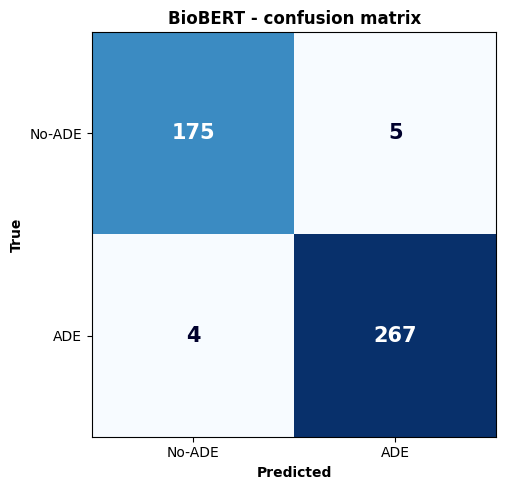

In [ ]:
pred = (test_proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['No-ADE', 'ADE'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['No-ADE', 'ADE'])
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('True', fontweight='bold')
ax.set_title(f'{MODEL_TITLE} - confusion matrix', fontweight='bold')
thr = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                fontsize=15, fontweight='bold',
                color='white' if cm[i, j] > thr else NAVY)
tn, fp, fn, tp = cm.ravel()
print(f'Missed-ADE (FN) rate: {fn / (fn + tp) if fn + tp else 0:.1%}')
plt.tight_layout(); plt.savefig(f'{MODEL_KEY}_confusion.png', dpi=200)
plt.show()

##  ROC curve

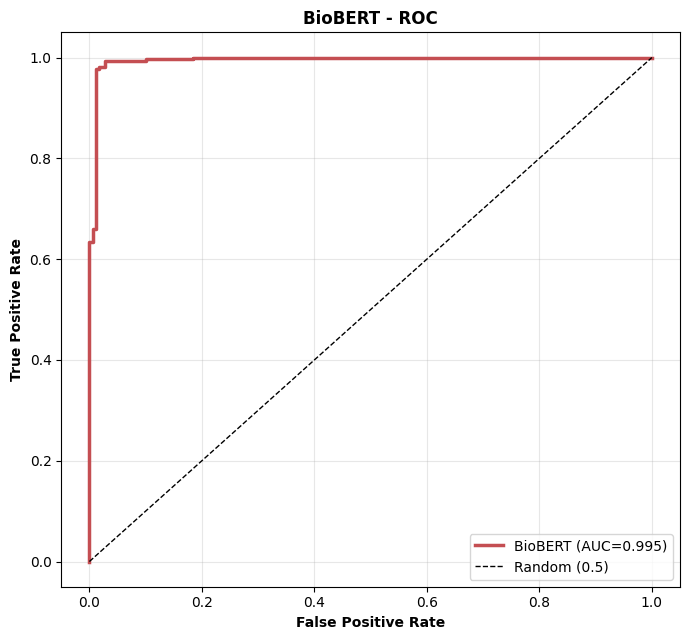

In [ ]:
fpr, tpr, _ = roc_curve(y_test, test_proba)
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.plot(fpr, tpr, lw=2.5, color=RED,
        label=f'{MODEL_TITLE} (AUC={auc(fpr, tpr):.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (0.5)')
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title(f'{MODEL_TITLE} - ROC', fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{MODEL_KEY}_roc.png', dpi=200)
plt.show()

##  Save the fine-tuned model
Saved and reloaded later by FAISS case retrieval and the Streamlit app - so they never retrain.

In [ ]:
bb.save_model(trainer, tok, 'biobert_model')
print('Saved fine-tuned BioBERT to ./biobert_model/')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved fine-tuned BioBERT to ./biobert_model/


## Cross-domain preview
Train on Formal, test on Informal - the honest generalisation check.

In [ ]:
cross = bb.run_cross_domain(full_df, 'Formal', 'Informal', epochs=3)
gap = pd.DataFrame([ev.degradation_row(MODEL_TITLE, metrics['f1'],
                                       cross['f1'])])
print(gap.to_string(index=False))

[biobert_finetune] AutoTokenizer failed (Couldn't instantiate the backend tokenizer from one of: 
(1) a `tokenizers` library serialization file, 
(2) a slow tokenizer instance to convert or 
(3) an equivalent slow tokenizer class to instantiate and convert. 
You need to have sentencepiece or tiktoken installed to convert a slow tokenizer to a fast one.); falling back to BertTokenizer.
[biobert_finetune] tokenizer ok: BertTokenizer (fallback)
[biobert_finetune] AutoModel failed (Unrecognized model in dmis-lab/biobert-base-cased-v1.1. Should have a `model_type` key in its config.json.); falling back to BertForSequenceClassification.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those

[biobert_finetune] model ok: BertForSequenceClassification (fallback)


Map:   0%|          | 0/2615 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/1246 [00:00<?, ? examples/s]

  model  f1_standard  f1_cross  degradation_pct
BioBERT       0.9834    0.9894             -0.6


## Export probabilities for ensembling


In [ ]:
# Probabilities (uid, label, <model>) - val trains the meta-learner,
# test evaluates it (leakage-free stack).
ev.save_probabilities(val_df, val_proba, MODEL_KEY,
                      f'probs_{MODEL_KEY}_val.csv')
ev.save_probabilities(test_df, test_proba, MODEL_KEY,
                      f'probs_{MODEL_KEY}_test.csv')

# Metrics + cross-domain gap (same schema as the other models)
pd.DataFrame([{'model': MODEL_TITLE, **metrics}]).to_csv(
    f'metrics_{MODEL_KEY}.csv', index=False)
gap.to_csv(f'gap_{MODEL_KEY}.csv', index=False)

print('Exported:',
      f'probs_{MODEL_KEY}_val.csv, probs_{MODEL_KEY}_test.csv,',
      f'metrics_{MODEL_KEY}.csv, gap_{MODEL_KEY}.csv')

Saved 470 probabilities -> probs_biobert_val.csv
Saved 451 probabilities -> probs_biobert_test.csv
Exported: probs_biobert_val.csv, probs_biobert_test.csv, metrics_biobert.csv, gap_biobert.csv


In [ ]:
# Check: made sure the export is ready for ensembling
_chk = pd.read_csv(f'probs_{MODEL_KEY}_test.csv')
assert {'uid', 'label', MODEL_KEY}.issubset(_chk.columns)
print(' verified - columns:', list(_chk.columns),
      '| rows:', len(_chk))

 verified - columns: ['uid', 'label', 'biobert'] | rows: 451
